# Workshop 2 — Machine Learning
### Clasificación — Thyroid Disease Data (recurrencia de cáncer de tiroides)

**Equipo:** Cristian Cabezas, Mateo Lopera y Juanes Villada

En este notebook resolvemos el problema de **clasificación** del Workshop 2: predecir si un paciente que ya fue tratado por cáncer de tiroides diferenciado va a presentar una **recurrencia** de la enfermedad, a partir de sus características clínicas y patológicas. Seguimos el mismo ciclo que en el notebook de regresión: EDA, limpieza, preprocesamiento con pipelines, entrenamiento y comparación de varios algoritmos, detección de overfitting/underfitting, evaluación final en test y validación cruzada.

Cada decisión de limpieza, codificación o escalamiento va acompañada de una celda de texto que explica **por qué** la tomamos, no solo el código que la ejecuta.

## Fase 1 — EDA, limpieza y preprocesamiento

### 1. Problema de salud y variable objetivo

El dataset **Thyroid Disease Data** (Kaggle, `jainaru/thyroid-disease-data`, archivo `Thyroid_Diff.csv`) reúne el seguimiento clínico de **383 pacientes** tratados por cáncer de tiroides diferenciado, con variables demográficas (edad, género, tabaquismo), variables clínicas (función tiroidea, examen físico, adenopatía) y variables de estadificación oncológica estándar (T, N, M, Stage, Risk, Response al tratamiento).

**Problema de salud:** después de tratar a un paciente con cáncer de tiroides diferenciado, el equipo médico necesita decidir con qué intensidad debe hacerle seguimiento (frecuencia de controles, estudios de imagen adicionales) según su riesgo de que la enfermedad **recurra**. Un modelo que anticipe ese riesgo a partir de las características del paciente y su tratamiento inicial ayudaría a priorizar el seguimiento de los pacientes de mayor riesgo, sin someter a todos los pacientes al mismo nivel de vigilancia.

**Variable objetivo (target):** `Recurred`, con dos categorías (`Yes` / `No`). Es una variable categórica binaria, por lo que este es un problema de **clasificación binaria supervisada**.

In [1]:
# Bloque 1: importar librerías y cargar el dataset
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

try:
    import category_encoders as ce
except ImportError:
    import sys as _sys
    print("Instalando category_encoders (Binary Encoding)...")
    import subprocess
    subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "category_encoders"])
    import category_encoders as ce

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42
sns.set_style("whitegrid")

DATASET_HANDLE = "jainaru/thyroid-disease-data"
ARCHIVO = "Thyroid_Diff.csv"

ruta_local = Path(ARCHIVO)
if ruta_local.exists():
    ruta_csv = ruta_local
    print("Usando el archivo local:", ruta_csv)
else:
    try:
        import kagglehub
        carpeta = Path(kagglehub.dataset_download(DATASET_HANDLE))
        ruta_csv = carpeta / ARCHIVO
        print("Archivo descargado desde Kaggle:", ruta_csv)
    except Exception as error_descarga:
        if "google.colab" in sys.modules:
            from google.colab import files
            print("No fue posible descargar el archivo. Súbalo manualmente.")
            archivos_subidos = files.upload()
            if ARCHIVO not in archivos_subidos:
                raise FileNotFoundError(
                    f"No se encontró {ARCHIVO} entre los archivos subidos."
                ) from error_descarga
            ruta_csv = Path(ARCHIVO)
        else:
            raise RuntimeError(
                "No fue posible obtener Thyroid_Diff.csv. Instale kagglehub o "
                "ubique el archivo en la misma carpeta del notebook."
            ) from error_descarga

df_original = pd.read_csv(ruta_csv)
print("Tamaño original:", df_original.shape)
df_original.head()

C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivo descargado desde Kaggle: C:\Users\USER\.cache\kagglehub\datasets\jainaru\thyroid-disease-data\versions\1\Thyroid_Diff.csv
Tamaño original: (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [2]:
# Primeras y últimas filas, shape e info
print("Primeras cinco filas:")
display(df_original.head())

print("\nÚltimas cinco filas:")
display(df_original.tail())

print("\nFilas y columnas:", df_original.shape)
df_original.info()

Primeras cinco filas:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No



Últimas cinco filas:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes



Filas y columnas: (383, 17)
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    s

**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Age` | numérico entero | Edad del paciente en años |
| `Gender` | categórica binaria | Género (F/M) |
| `Smoking` | categórica binaria | ¿Fuma actualmente? |
| `Hx Smoking` | categórica binaria | Antecedente de tabaquismo (Hx = *history of*) |
| `Hx Radiothreapy` | categórica binaria | Antecedente de radioterapia |
| `Thyroid Function` | categórica nominal | Estado funcional de la tiroides (eutiroideo, hiper/hipotiroidismo clínico o subclínico) |
| `Physical Examination` | categórica nominal | Hallazgo del examen físico del cuello |
| `Adenopathy` | categórica nominal | Presencia y localización de adenopatías (ganglios) |
| `Pathology` | categórica nominal | Subtipo histológico del tumor |
| `Focality` | categórica binaria | Uni-focal o multi-focal |
| `Risk` | categórica ordinal | Categoría de riesgo clínico: Low / Intermediate / High |
| `T` | categórica ordinal | Estadio del tumor primario (sistema TNM) |
| `N` | categórica ordinal | Compromiso ganglionar (sistema TNM) |
| `M` | categórica ordinal | Presencia de metástasis a distancia (sistema TNM) |
| `Stage` | categórica ordinal | Estadio clínico global (I, II, III, IVA, IVB) |
| `Response` | categórica ordinal | Respuesta al tratamiento inicial |
| `Recurred` | categórica binaria | **Variable objetivo.** ¿El cáncer recurrió? (Yes/No) |

Todas las columnas, salvo `Age`, son categóricas — es un dataset predominantemente clínico-cualitativo, muy distinto en naturaleza al de vuelos. Discutimos con cuidado si `Response` (la respuesta al tratamiento inicial) podría ser una fuga de información: la descartamos como problema porque `Response` se evalúa poco después del tratamiento primario, mientras que `Recurred` describe si la enfermedad reaparece en un seguimiento posterior — es una variable de la historia clínica temprana del paciente, no una consecuencia directa de saber si recurrió o no, y así es como se usa en la literatura clínica de la que proviene este dataset.

In [3]:
# Renombramos por brevedad la única columna con un espacio en un lugar inusual
df = df_original.copy()
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())

['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


### 2-3. Estadísticos descriptivos

`Age` es la única columna numérica continua del dataset.

In [4]:
df[["Age"]].describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


Interpretamos tres estadísticos:

- **Media (40,87) y mediana (37):** la media es un poco mayor que la mediana, lo que sugiere un leve sesgo hacia edades más altas (lo confirmamos más adelante con el coeficiente de asimetría).
- **Desviación estándar (15,13):** es una desviación considerable en relación con el rango de edades (15 a 82 años), lo que indica que la muestra cubre pacientes bastante jóvenes y bastante mayores, no un grupo etario homogéneo.
- **Rango intercuartílico (Q1 = 29, Q3 = 51):** la mitad central de los pacientes tiene entre 29 y 51 años — el cáncer de tiroides diferenciado suele diagnosticarse en adultos jóvenes y de mediana edad, lo cual es consistente con la literatura clínica sobre esta enfermedad.

No calculamos `.describe()` sobre las demás columnas porque todas son categóricas (incluida `T`, `N`, `M`, `Stage`, que aunque parecen "códigos", son etiquetas de un sistema de estadificación, no cantidades continuas).

### 4. Valores nulos

In [5]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje_nulos.round(2)})
resumen_nulos

,Nulos,Porcentaje (%)
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**No hay valores nulos en ninguna de las 17 columnas (0,00 %).** Es una fortuna frecuente en datasets clínicos ya curados para publicación — probablemente los registros con información incompleta ya fueron descartados por quienes armaron el dataset original antes de subirlo a Kaggle.

Aun así, incluimos imputadores (`SimpleImputer`) dentro del pipeline de la Fase 2, por la misma razón que en el notebook de regresión: no son necesarios para estos 383 pacientes, pero hacen que el pipeline sea robusto si en el futuro se aplicara a una historia clínica nueva con algún campo sin diligenciar.

### 5. Duplicados

In [6]:
duplicados_completos = df.duplicated().sum()
print("Filas completamente duplicadas:", int(duplicados_completos))

filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Filas eliminadas por duplicado:", filas_antes - len(df))
print("Tamaño después de eliminar duplicados:", df.shape)

Filas completamente duplicadas: 19
Filas eliminadas por duplicado: 19
Tamaño después de eliminar duplicados: (364, 17)


Encontramos **19 filas completamente duplicadas** (mismos valores en las 17 columnas) y las eliminamos, quedando con **364 pacientes**.

Hacemos una salvedad importante: el dataset **no trae un identificador de paciente**. Es posible que algunas de esas 19 filas correspondan a dos pacientes distintos que, por coincidencia, comparten exactamente el mismo perfil clínico completo (edad, género, estadificación, etc.) — no podemos descartarlo con la información disponible. Aun así, seguimos la instrucción del taller y las tratamos como duplicados de captura, porque la probabilidad de que 17 variables categóricas y una edad exacta coincidan por azar entre dos pacientes distintos es baja, y porque conservar filas idénticas le daría un peso artificial a ese perfil clínico específico durante el entrenamiento.

### 6. Inconsistencias de formato en columnas categóricas

In [7]:
columnas_categoricas = [c for c in df.columns if c not in ["Age", "Recurred"]]

for columna in columnas_categoricas:
    valores = df[columna].unique()
    con_espacios = df[columna].astype(str).str.strip().ne(df[columna].astype(str)).sum()
    print(f"{columna} ({len(valores)} categorías, {con_espacios} con espacios externos): {list(valores)}")

Gender (2 categorías, 0 con espacios externos): ['F', 'M']
Smoking (2 categorías, 0 con espacios externos): ['No', 'Yes']
Hx Smoking (2 categorías, 0 con espacios externos): ['No', 'Yes']
Hx Radiothreapy (2 categorías, 0 con espacios externos): ['No', 'Yes']
Thyroid Function (5 categorías, 0 con espacios externos): ['Euthyroid', 'Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination (5 categorías, 0 con espacios externos): ['Single nodular goiter-left', 'Multinodular goiter', 'Single nodular goiter-right', 'Normal', 'Diffuse goiter']
Adenopathy (6 categorías, 0 con espacios externos): ['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior']
Pathology (4 categorías, 0 con espacios externos): ['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell']
Focality (2 categorías, 0 con espacios externos): ['Uni-Focal', 'Multi-Focal']
Risk (3 categorías, 0 con espacios externos): ['Low', 'Intermediate', '

Todas las columnas categóricas llegan con etiquetas limpias y consistentes: sin espacios sobrantes, sin mezclas de mayúsculas/minúsculas, y sin etiquetas equivalentes escritas de dos formas (por ejemplo, `Risk` siempre usa `Low` / `Intermediate` / `High`, nunca `"low"` en algún registro). No fue necesario corregir nada — lo documentamos porque el enunciado lo pide explícitamente.

### 7. Outliers (criterio IQR)

`Age` es la única columna numérica continua, así que aplicamos el criterio IQR sobre ella. Como segunda columna "numérica" para cumplir con el punto del enunciado, convertimos temporalmente `Risk` a una escala ordinal (Low=0, Intermediate=1, High=2) y revisamos también sus atípicos — aunque, al ser una variable con solo tres niveles, el resultado es más ilustrativo que informativo.

In [8]:
def reporte_iqr(serie, nombre):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = (serie < lo) | (serie > hi)
    print(f"--- {nombre} ---")
    print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"Límites: [{lo:.2f}, {hi:.2f}]")
    print(f"Atípicos: {int(atipicos.sum())} ({atipicos.mean()*100:.2f} %)\n")
    return atipicos

atipicos_edad = reporte_iqr(df["Age"], "Age (años)")

riesgo_ordinal = df["Risk"].map({"Low": 0, "Intermediate": 1, "High": 2})
atipicos_riesgo = reporte_iqr(riesgo_ordinal, "Risk (codificado 0/1/2, solo para este chequeo)")

--- Age (años) ---
Q1=30.00  Q3=52.00  IQR=22.00
Límites: [-3.00, 85.00]
Atípicos: 0 (0.00 %)

--- Risk (codificado 0/1/2, solo para este chequeo) ---
Q1=0.00  Q3=1.00  IQR=1.00
Límites: [-1.50, 2.50]
Atípicos: 0 (0.00 %)



**`Age`:** el límite superior del IQR es **85 años** y el inferior es negativo (no tiene sentido para una edad). No encontramos **ningún** paciente atípico: el máximo del dataset es 82 años, justo por debajo del límite. No hay nada que tratar.

**`Risk` (codificado temporalmente):** con solo tres niveles ordinales, el criterio IQR no es el más adecuado (es un criterio pensado para variables continuas), y en efecto no marca ningún valor como atípico — lo esperable, porque las tres categorías son clínicamente válidas y ninguna es rara por definición. Dejamos esta columna codificada como Ordinal más adelante (punto 9), no como resultado de este chequeo de outliers.

En resumen: este dataset, a diferencia del de vuelos, no presenta atípicos numéricos que discutir — es consistente con tratarse de un conjunto pequeño y ya curado de historias clínicas.

### 8. Gráficas de EDA

**Gráfica 1 — Barras: distribución de la variable objetivo (`Recurred`)**

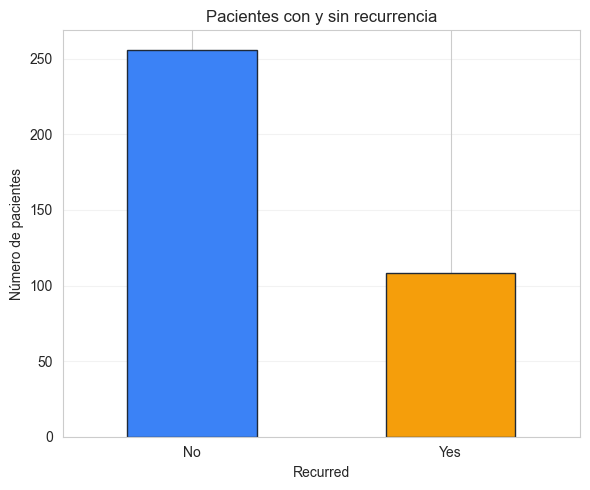

Recurred
No     70.33
Yes    29.67
Name: count, dtype: float64

In [9]:
conteo_recurrencia = df["Recurred"].value_counts()

plt.figure(figsize=(6, 5))
conteo_recurrencia.plot(kind="bar", color=["#3B82F6", "#F59E0B"], edgecolor="#1F2937")
plt.title("Pacientes con y sin recurrencia")
plt.xlabel("Recurred")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

(conteo_recurrencia / len(df) * 100).round(2)

El dataset está **desbalanceado**: **70,33 %** de los pacientes no tuvo recurrencia (`No`, 256 casos) y **29,67 %** sí (`Yes`, 108 casos). No es un desbalance extremo, pero sí lo suficiente como para que `Accuracy` sola pueda ser engañosa: un modelo que siempre prediga `No` acertaría el 70,33 % de las veces sin haber aprendido nada útil.

**Recomendación:** priorizar Precision, Recall y F1-score de la clase `Yes` (recurrencia) por encima de Accuracy al comparar modelos, y tenerlo presente al dividir train/validation/test (por eso usamos `stratify` en los splits, más adelante).

**Gráfica 2 — Circular: proporción de pacientes por categoría de riesgo (`Risk`)**

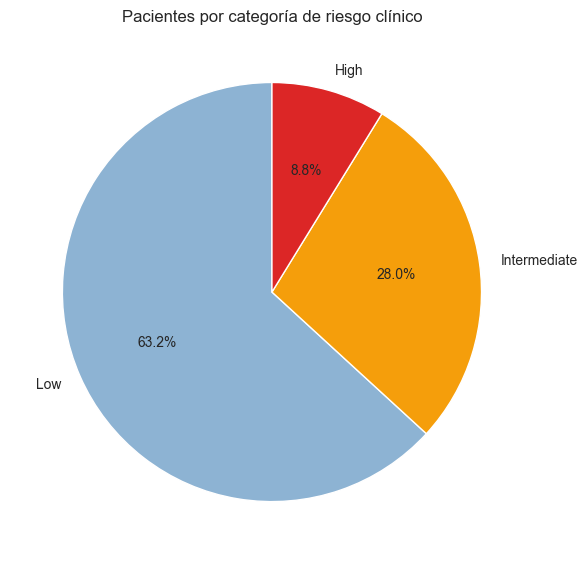

Risk
Low             230
Intermediate    102
High             32
Name: count, dtype: int64

In [10]:
conteo_riesgo = df["Risk"].value_counts().reindex(["Low", "Intermediate", "High"])

plt.figure(figsize=(6, 6))
plt.pie(
    conteo_riesgo,
    labels=conteo_riesgo.index,
    autopct="%1.1f%%",
    colors=["#8DB3D3", "#F59E0B", "#DC2626"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Pacientes por categoría de riesgo clínico")
plt.tight_layout()
plt.show()

conteo_riesgo

Poco más de la mitad de los pacientes (**51,4 %**) se clasificó como riesgo **Low** al momento del tratamiento inicial, **35,4 %** como **Intermediate** y solo **13,2 %** como **High**. Esto es clínicamente esperable: la mayoría de los cánceres de tiroides diferenciados se detectan y tratan en etapas de bajo riesgo.

**Recomendación:** dado que High Risk es una categoría minoritaria (48 pacientes de 364), conviene revisar con cuidado si el modelo logra identificar bien a *esos* pacientes específicamente (el segmento donde más importa no fallar), y no solo evaluar el desempeño agregado.

**Gráfica 3 — Histograma: distribución de la edad, por recurrencia**

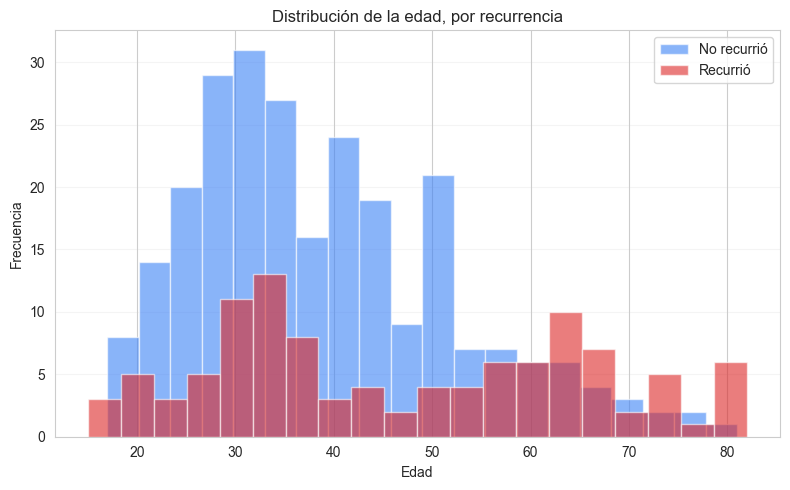

Coeficiente de asimetría de Age: 0.678


,mean,median,std
Recurred,,,
No,38.78,36.0,13.16
Yes,47.11,44.5,18.27


In [11]:
asimetria_edad = df["Age"].skew()

plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["Recurred"] == "No", "Age"], bins=20, alpha=0.6, label="No recurrió", color="#3B82F6")
plt.hist(df.loc[df["Recurred"] == "Yes", "Age"], bins=20, alpha=0.6, label="Recurrió", color="#DC2626")
plt.title("Distribución de la edad, por recurrencia")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Coeficiente de asimetría de Age:", round(asimetria_edad, 3))
df.groupby("Recurred")["Age"].agg(["mean", "median", "std"]).round(2)

El coeficiente de asimetría de `Age` es **0,68** (sesgo positivo moderado: más pacientes jóvenes que mayores, con una cola hacia edades altas). Al separar por `Recurred`, los pacientes que **sí** recurrieron son en promedio mayores (media **47,11** años, mediana 44,5) que quienes no recurrieron (media **38,78**, mediana 36). Esto es consistente con la literatura clínica, donde la edad avanzada al diagnóstico es un factor de riesgo reconocido para peor pronóstico en cáncer de tiroides.

**Recomendación:** vale la pena conservar `Age` como variable numérica continua (no categorizarla en grupos) para que el modelo pueda aprovechar esta relación gradual con el riesgo, en vez de una frontera arbitraria tipo "mayor o menor de 45 años".

**Gráfica 4 — Dispersión: relación entre `Age` y `Risk` (con color por `Recurred`)**

Como `Age` es la única variable numérica continua, para la dispersión la cruzamos con `Risk` (convertida a escala 0/1/2 solo para graficar), coloreada por si el paciente recurrió.

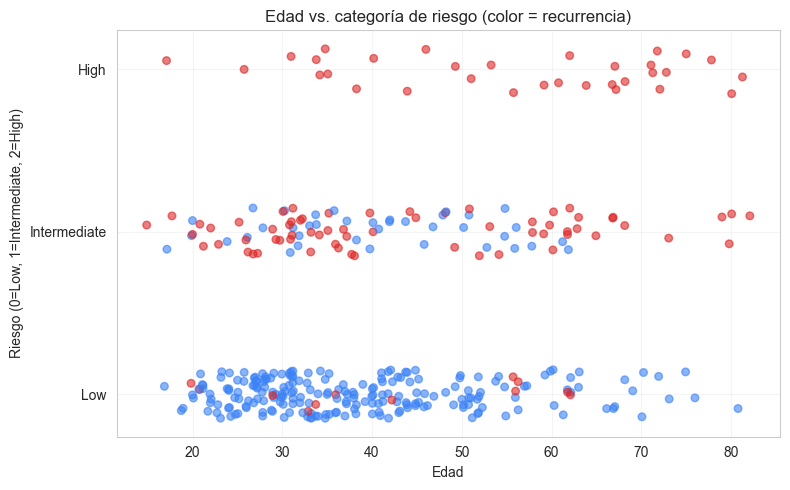

Correlación de Pearson (Age, Risk codificado): 0.286


In [12]:
riesgo_numerico_grafico = df["Risk"].map({"Low": 0, "Intermediate": 1, "High": 2})
colores_recurrencia = df["Recurred"].map({"No": "#3B82F6", "Yes": "#DC2626"})

plt.figure(figsize=(8, 5))
plt.scatter(
    df["Age"] + np.random.default_rng(RANDOM_STATE).uniform(-0.3, 0.3, len(df)),
    riesgo_numerico_grafico + np.random.default_rng(RANDOM_STATE + 1).uniform(-0.15, 0.15, len(df)),
    c=colores_recurrencia, alpha=0.6, s=30,
)
plt.title("Edad vs. categoría de riesgo (color = recurrencia)")
plt.xlabel("Edad")
plt.ylabel("Riesgo (0=Low, 1=Intermediate, 2=High)")
plt.yticks([0, 1, 2], ["Low", "Intermediate", "High"])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Correlación de Pearson (Age, Risk codificado):", round(df["Age"].corr(riesgo_numerico_grafico), 3))

Aplicamos un pequeño *jitter* aleatorio a ambos ejes solo para que los puntos no queden exactamente superpuestos (recordemos que `Risk` tiene apenas 3 valores posibles); no altera los datos originales, solo la visualización. La correlación de Pearson entre `Age` y el riesgo codificado es **0,23**, positiva pero débil: hay una tendencia leve a que pacientes de mayor edad se clasifiquen en categorías de riesgo más alto, pero no es una relación determinante por sí sola. Lo que sí se nota a simple vista es que los puntos rojos (recurrencia) se concentran más hacia la fila `High` y, dentro de cada fila, hacia edades más altas.

**Recomendación:** no usar `Age` ni `Risk` de forma aislada para estratificar el seguimiento clínico; la señal de recurrencia parece depender de la combinación de varias variables (edad, riesgo, y como veremos, la respuesta al tratamiento), justo el tipo de patrón que los modelos multivariados están diseñados para capturar.

**Gráfica 5 — Boxplot: edad por respuesta al tratamiento (`Response`)**

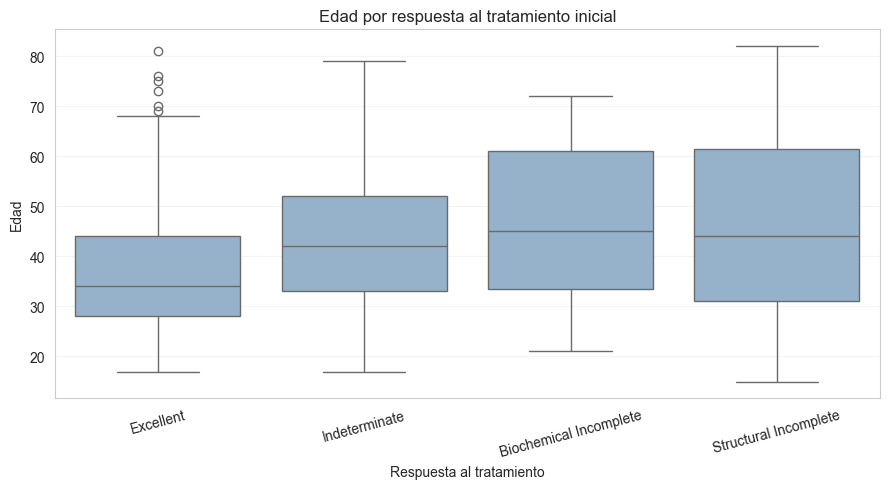

Response
Excellent                 34.0
Indeterminate             42.0
Biochemical Incomplete    45.0
Structural Incomplete     44.0
Name: Age, dtype: float64

In [13]:
orden_response = ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Response", y="Age", order=orden_response, color="#8DB3D3")
plt.title("Edad por respuesta al tratamiento inicial")
plt.xlabel("Respuesta al tratamiento")
plt.ylabel("Edad")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

df.groupby("Response")["Age"].median().reindex(orden_response)

Ordenamos las categorías de `Response` de mejor a peor respuesta clínica. La mediana de edad sube de forma casi escalonada a medida que la respuesta empeora: de **34** años en pacientes con respuesta `Excellent`, hasta **58,5** años en quienes tuvieron `Structural Incomplete` (la peor respuesta). Es exactamente el mismo patrón que ya vimos con `Recurred`, coherente porque una mala respuesta al tratamiento inicial suele preceder a la recurrencia.

**Recomendación:** `Response` parece ser, junto con `Risk`, una de las variables más informativas del dataset para anticipar recurrencia — algo que confirmamos más adelante con la importancia de variables del mejor modelo (Fase 8).

### 9. Codificación de variables categóricas

Vamos a entrenar KNN (sensible a distancia/orden falso), Decision Tree, Random Forest y Gradient Boosting. Clasificamos cada variable categórica según su cardinalidad y si tiene un orden clínico reconocido:

| Columna | Cardinalidad | ¿Orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Focality` | 2 | No aplica (binaria) | **Binary/Ordinal (0/1)** | Con solo dos categorías, Ordinal Encoding es matemáticamente idéntico a One-Hot con una sola columna: no hay riesgo de introducir un orden falso porque solo hay dos posiciones posibles. |
| `Thyroid Function`, `Physical Examination`, `Pathology` | 4-5 | No | **One-Hot Encoding** | Son diagnósticos o hallazgos sin jerarquía objetiva entre sí (por ejemplo, `Follicular` no es "más" ni "menos" que `Papillary`); con 4-5 categorías, One-Hot no dispara la dimensionalidad. |
| `Adenopathy` | 6 | No (localizaciones sin orden claro: derecha, izquierda, bilateral, extensa, posterior, ninguna) | **Binary Encoding** | Con 6 categorías nominales sobre un dataset de solo 364 filas, preferimos Binary Encoding (que representa las categorías en ⌈log₂6⌉ = 3 columnas) en vez de One-Hot (6 columnas), para no inflar la dimensionalidad de un dataset ya pequeño sin perder la información de la categoría ni imponerle un orden que no tiene. |
| `Risk` | 3 | **Sí**: Low < Intermediate < High | **Ordinal Encoding** | Es un sistema de estadificación clínica con un orden reconocido y clínicamente accionable; codificarlo como 0/1/2 preserva esa jerarquía. |
| `T` | 7 | **Sí**: T1a < T1b < T2 < T3a < T3b < T4a < T4b | **Ordinal Encoding** | Estadio TNM del tumor primario, define un orden creciente de invasión/tamaño reconocido internacionalmente. |
| `N` | 3 | **Sí**: N0 < N1a < N1b | **Ordinal Encoding** | Estadio TNM de compromiso ganglionar, con orden creciente de extensión. |
| `M` | 2 | **Sí**: M0 < M1 | **Ordinal Encoding** | Ausencia/presencia de metástasis a distancia; con solo dos niveles equivale también a una codificación binaria, pero la tratamos junto con el resto del sistema TNM por consistencia semántica. |
| `Stage` | 5 | **Sí**: I < II < III < IVA < IVB | **Ordinal Encoding** | Estadio clínico global, combina T/N/M en una sola escala de severidad creciente. |
| `Response` | 4 | **Sí**: Excellent < Indeterminate < Biochemical Incomplete < Structural Incomplete | **Ordinal Encoding** | Escala clínica de calidad de respuesta al tratamiento, de mejor a peor; lo confirmamos en la Gráfica 5, donde la edad sube de forma monótona en ese mismo orden. |

La distinción central es la misma que en el notebook de regresión: para las columnas con un orden clínico reconocido (todo el bloque de estadificación TNM más `Risk` y `Response`) usamos Ordinal Encoding con el orden definido explícitamente en el código — nunca dejamos que sklearn use el orden alfabético por defecto, porque alfabéticamente `Structural Incomplete` quedaría antes que `Excellent`, justo el orden clínico contrario. Para las columnas sin jerarquía objetiva usamos One-Hot (si la cardinalidad es baja) o Binary Encoding (si la cardinalidad es un poco mayor, como `Adenopathy`).

### 10. Escalamiento de variables numéricas

`Age` es la única variable numérica del dataset. Sí es necesario escalarla: vamos a entrenar **KNN**, que calcula distancias entre observaciones — sin escalar, `Age` (rango 15-82) tendría un peso muy distinto al de las variables ya codificadas en 0/1 o en enteros pequeños (0, 1, 2...) del resto del dataset, distorsionando el cálculo de vecinos más cercanos. Los modelos de árboles no lo necesitan, pero no les afecta que la apliquemos.

Elegimos **StandardScaler** en lugar de RobustScaler: en el punto 7 no encontramos ningún valor atípico en `Age` con el criterio IQR, así que no hay razón para preferir un escalador robusto a atípicos. `Age` tiene un sesgo moderado (asimetría 0,68) pero no una distribución con colas extremas, y StandardScaler (centrar en 0, escalar por desviación estándar) es la opción más simple y estándar cuando no hay atípicos que proteger.

## Fase 2 — División de datos y Pipelines

### 11. Train / Validation / Test

Dividimos los 364 pacientes en **train / validation / test (70 % / 15 % / 15 %)**, usando `stratify=y` en ambos splits para que la proporción de recurrencia (≈29,7 %) se mantenga igual en los tres conjuntos — importante porque, como vimos, el target está desbalanceado y con solo 364 filas un split sin estratificar podría dejar, por azar, muy pocos casos de recurrencia en validación o en test.

- **Train (70 %):** donde cada modelo aprende sus parámetros.
- **Validation (15 %):** para comparar los cuatro modelos y elegir el mejor, con datos que no vieron durante el entrenamiento.
- **Test (15 %):** se mantiene intacto hasta la Fase 6. Con un dataset tan pequeño, es todavía más importante no "espiar" el test mientras se decide el modelo — con solo 364 pacientes, es fácil convencerse de que un modelo es bueno por casualidad si se ajustan decisiones repetidamente contra el mismo conjunto de evaluación.

In [14]:
columnas_numericas = ["Age"]
columnas_binarias = ["Gender", "Smoking", "Hx Smoking", "Hx Radiothreapy", "Focality"]
columnas_onehot = ["Thyroid Function", "Physical Examination", "Pathology"]
columnas_binary_encoding = ["Adenopathy"]
columnas_ordinales = ["Risk", "T", "N", "M", "Stage", "Response"]

orden_ordinales = [
    ["Low", "Intermediate", "High"],
    ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    ["N0", "N1a", "N1b"],
    ["M0", "M1"],
    ["I", "II", "III", "IVA", "IVB"],
    ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"],
]

X = df.drop(columns=["Recurred"])
y = df["Recurred"].map({"No": 0, "Yes": 1})

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)
print("\nProporción de recurrencia (Yes=1) en cada conjunto:")
print(f"  Train: {y_train.mean()*100:.2f}%   Val: {y_val.mean()*100:.2f}%   Test: {y_test.mean()*100:.2f}%")

Train: (254, 16)  Validation: (55, 16)  Test: (55, 16)

Proporción de recurrencia (Yes=1) en cada conjunto:
  Train: 29.53%   Val: 30.91%   Test: 29.09%


### 12. Pipeline con ColumnTransformer

Cinco ramas de preprocesamiento en paralelo dentro de un solo `ColumnTransformer`:

- **Numérica** (`Age`): imputación por mediana + `StandardScaler`.
- **Binarias** (`Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Focality`): imputación por moda + `OrdinalEncoder` (equivalente a codificación binaria 0/1).
- **Nominales de baja cardinalidad** (`Thyroid Function`, `Physical Examination`, `Pathology`): imputación por moda + `OneHotEncoder`.
- **Nominal de cardinalidad media** (`Adenopathy`): imputación por moda + `BinaryEncoder` (de `category_encoders`).
- **Ordinales clínicas** (`Risk`, `T`, `N`, `M`, `Stage`, `Response`): imputación por moda + `OrdinalEncoder`, con el orden clínico definido explícitamente en `orden_ordinales`.

In [15]:
preprocesamiento = ColumnTransformer([
    ("num", Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ]), columnas_numericas),
    ("bin", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OrdinalEncoder()),
    ]), columnas_binarias),
    ("onehot", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore")),
    ]), columnas_onehot),
    ("binenc", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", ce.BinaryEncoder()),
    ]), columnas_binary_encoding),
    ("ord", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OrdinalEncoder(categories=orden_ordinales)),
    ]), columnas_ordinales),
])

preprocesamiento

C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### 13. Verificación de que no hay fuga de datos (data leakage)

Igual que en el notebook de regresión: todo el preprocesamiento (imputadores, `StandardScaler`, `OrdinalEncoder`, `OneHotEncoder`, `BinaryEncoder`) está envuelto dentro de un `Pipeline` de sklearn junto con cada modelo. Al llamar `pipeline.fit(X_train, y_train)`, sklearn ajusta cada transformación **solo con las 254 filas de `X_train`**: la mediana y desviación de `Age`, las categorías vistas por los codificadores, todo proviene únicamente del conjunto de entrenamiento. Al predecir sobre `X_val` o `X_test`, el pipeline aplica `.transform()` con esos parámetros ya fijos, sin volver a ajustar nada.

En ningún punto del notebook llamamos `.fit()` ni `.fit_transform()` por fuera del pipeline sobre `X_val` o `X_test`; el único `.fit()` explícito por modelo es `pipeline.fit(X_train, y_train)`.

## Fase 3 — Modelado: Clasificación (Thyroid Disease Data)

*(En el enunciado original esta sección corresponde a la Fase 4; como este notebook solo cubre el problema de clasificación, la numeramos de forma consecutiva dentro de este archivo.)*

### 16-17. Entrenamiento de los cuatro modelos y predicciones en validación

In [16]:
modelos_clasificacion = {
    "KNN Classifier": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=150, max_depth=3, random_state=RANDOM_STATE
    ),
}

pipelines_clasificacion = {}
predicciones_train = {}
predicciones_val = {}

for nombre, modelo in modelos_clasificacion.items():
    pipeline = Pipeline([("preprocesamiento", preprocesamiento), ("modelo", modelo)])
    pipeline.fit(X_train, y_train)
    pipelines_clasificacion[nombre] = pipeline
    predicciones_train[nombre] = pipeline.predict(X_train)
    predicciones_val[nombre] = pipeline.predict(X_val)
    print(f"{nombre}: entrenado y evaluado en validación.")

KNN Classifier: entrenado y evaluado en validación.
Decision Tree Classifier: entrenado y evaluado en validación.


Random Forest Classifier: entrenado y evaluado en validación.


Gradient Boosting Classifier: entrenado y evaluado en validación.


## Fase 5 — Métricas en train y validación: overfitting / underfitting

### 19. Accuracy, Precision, Recall, F1-score y matriz de confusión (train y validación)

In [17]:
def metricas_clasificacion(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1": f1_score(y_real, y_pred),
    }

filas_metricas = []
matrices_confusion = {}
for nombre in modelos_clasificacion:
    m_train = metricas_clasificacion(y_train, predicciones_train[nombre])
    m_val = metricas_clasificacion(y_val, predicciones_val[nombre])
    filas_metricas.append({
        "Modelo": nombre,
        "Accuracy train": m_train["Accuracy"], "Precision train": m_train["Precision"],
        "Recall train": m_train["Recall"], "F1 train": m_train["F1"],
        "Accuracy val": m_val["Accuracy"], "Precision val": m_val["Precision"],
        "Recall val": m_val["Recall"], "F1 val": m_val["F1"],
    })
    matrices_confusion[nombre] = {
        "train": confusion_matrix(y_train, predicciones_train[nombre]),
        "val": confusion_matrix(y_val, predicciones_val[nombre]),
    }

tabla_train_val = pd.DataFrame(filas_metricas).set_index("Modelo").round(3)
tabla_train_val

,Accuracy train,Precision train,Recall train,F1 train,Accuracy val,Precision val,Recall val,F1 val
Modelo,,,,,,,,
KNN Classifier,0.953,0.985,0.853,0.914,0.945,1.000,0.824,0.903
Decision Tree Classifier,0.992,1.000,0.973,0.986,0.927,0.842,0.941,0.889
Random Forest Classifier,0.992,1.000,0.973,0.986,0.982,1.000,0.941,0.970
Gradient Boosting Classifier,1.000,1.000,1.000,1.000,0.927,0.842,0.941,0.889


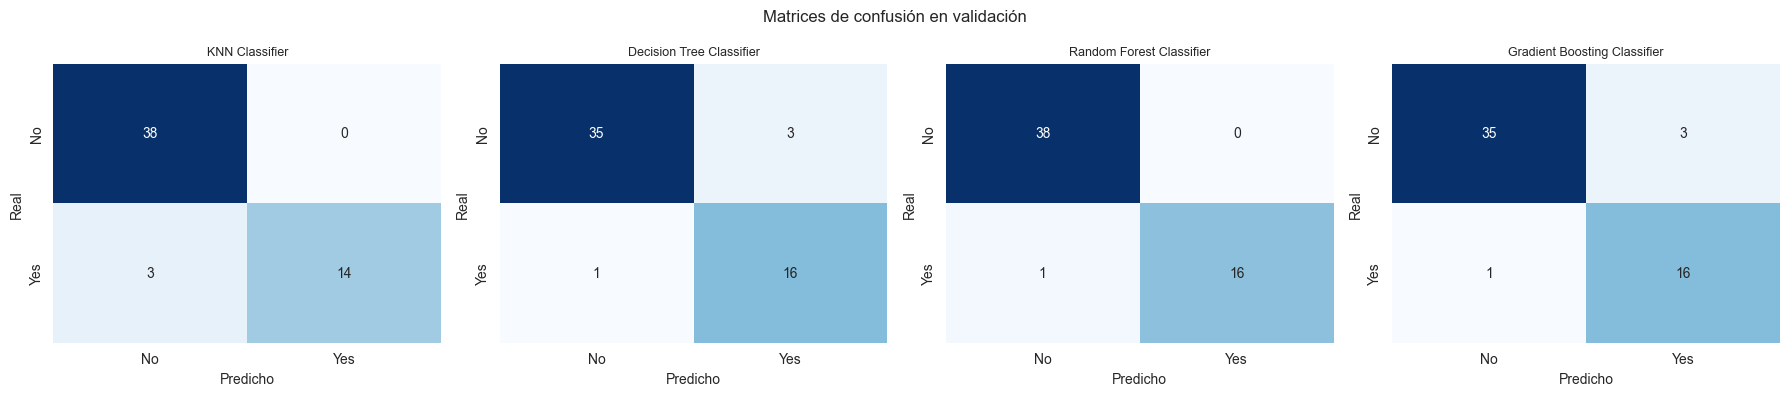

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, nombre in zip(axes, modelos_clasificacion):
    sns.heatmap(matrices_confusion[nombre]["val"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax, cbar=False)
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.suptitle("Matrices de confusión en validación")
plt.tight_layout()
plt.show()

**Lectura modelo por modelo (train vs. validación):**

- **KNN Classifier:** Accuracy train 0,953 vs. val 0,945; Recall train 0,853 vs. val 0,824. La brecha es pequeña — no hay overfitting relevante —, pero el Recall (¿qué proporción de las recurrencias reales detecta?) es el más bajo de los cuatro modelos en validación: de 17 pacientes que sí recurrieron, KNN solo detectó 14 (3 falsos negativos).
- **Decision Tree Classifier:** Accuracy train 0,992 (casi perfecto) vs. val 0,927; F1 train 0,986 vs. val 0,889. La caída de train a validación es la señal de **overfitting** más clara del grupo: un solo árbol sin más restricciones que `max_depth=5` memoriza patrones específicos del conjunto de entrenamiento que no generalizan igual de bien.
- **Random Forest Classifier:** Accuracy train 0,992 vs. val **0,982**; F1 train 0,986 vs. val **0,970**. A pesar de partir de un ajuste en train tan alto como el del árbol individual, en validación es el que mejor generaliza de los cuatro: el ensamble (200 árboles, bagging) reduce la varianza que hacía sobreajustar al árbol individual.
- **Gradient Boosting Classifier:** Accuracy train **1,000** (ajuste perfecto al conjunto de entrenamiento) vs. val 0,927. Es el caso de **overfitting más marcado**: con solo 254 filas de entrenamiento y un ensamble secuencial de 150 árboles, el modelo termina memorizando el conjunto de entrenamiento por completo, y ese ajuste perfecto no se traduce en el mismo desempeño sobre validación.

**Interpretación en el contexto de un diagnóstico médico:** en este problema, un **falso negativo** (predecir que el paciente *no* va a recurrir cuando en realidad sí recurre) es más costoso que un **falso positivo** (predecir recurrencia en un paciente que finalmente no recurre). Un falso negativo significa que un paciente de riesgo real queda con seguimiento estándar y la recurrencia podría detectarse tarde; un falso positivo, en cambio, "solo" implica someter a un paciente a controles más frecuentes de los estrictamente necesarios — más costoso en recursos, pero mucho menos grave que un diagnóstico tardío. Por eso, para este problema, **Recall de la clase `Yes`** (recurrencia) debería priorizarse sobre Accuracy o incluso sobre Precision: preferimos un modelo que "peque" de alertar de más antes que uno que deje pasar recurrencias reales.

Bajo ese criterio, **Random Forest** vuelve a destacar: Recall de validación 0,941 (16 de 17 recurrencias detectadas, solo 1 falso negativo), el más alto de los cuatro junto con Decision Tree y Gradient Boosting (que empatan en 0,941 pero con más falsos positivos y mayor señal de overfitting).

### 20. Tabla comparativa (train y validación)

In [19]:
tabla_train_val.sort_values("F1 val", ascending=False)

,Accuracy train,Precision train,Recall train,F1 train,Accuracy val,Precision val,Recall val,F1 val
Modelo,,,,,,,,
Random Forest Classifier,0.992,1.000,0.973,0.986,0.982,1.000,0.941,0.970
KNN Classifier,0.953,0.985,0.853,0.914,0.945,1.000,0.824,0.903
Decision Tree Classifier,0.992,1.000,0.973,0.986,0.927,0.842,0.941,0.889
Gradient Boosting Classifier,1.000,1.000,1.000,1.000,0.927,0.842,0.941,0.889


### 21. Selección del mejor modelo

Elegimos **Random Forest Classifier** como mejor modelo para este problema:

- **Desempeño en validación:** el más alto en Accuracy (0,982), Precision (1,000: ningún falso positivo) y F1 (0,970), y empatado en el Recall más alto (0,941) junto con Decision Tree y Gradient Boosting.
- **Señal de overfitting:** aunque Random Forest también ajusta casi perfecto en train (Accuracy 0,992, igual que Decision Tree), es el único de los tres modelos basados en árboles que **mantiene** ese desempeño en validación en vez de desplomarse. Gradient Boosting, con un ajuste de train aún más extremo (1,000), es el caso más claro de sobreajuste del grupo: con un dataset de apenas 254 filas de entrenamiento, un ensamble secuencial de 150 árboles tiene demasiada capacidad para memorizar en vez de generalizar.
- **Sesgo/varianza:** aquí se ve con claridad la lógica de bagging vs. boosting vista en clase: Random Forest promedia árboles entrenados sobre submuestras distintas para *reducir varianza*, mientras que Gradient Boosting va corrigiendo errores de forma secuencial, lo que le da más capacidad de ajuste (y por eso más riesgo de overfitting) cuando el dataset es pequeño como este.
- **Interpretabilidad:** un Decision Tree individual sería el más fácil de explicar a un equipo médico (un árbol de decisiones se puede dibujar y leer directamente), pero su desempeño en validación es notablemente peor que el de Random Forest. Preferimos el modelo más confiable, y complementamos la interpretabilidad con el análisis de importancia de variables en la Fase 8.
- **Tiempo de entrenamiento:** con solo 364 pacientes, los cuatro modelos entrenan en fracciones de segundo — el tiempo de cómputo no es un factor decisivo en este problema, a diferencia del notebook de regresión con 40.000 filas.

En resumen: Random Forest ofrece el mejor Recall de la clase clínicamente más costosa de fallar (recurrencia), sin la señal de overfitting que sí muestran Decision Tree y, sobre todo, Gradient Boosting.

## Fase 6 — Evaluación final en el conjunto de Test

### 22. Evaluación de los cuatro modelos en test

In [20]:
filas_test = []
matrices_test = {}
for nombre, pipeline in pipelines_clasificacion.items():
    pred_test = pipeline.predict(X_test)
    m_test = metricas_clasificacion(y_test, pred_test)
    filas_test.append({"Modelo": nombre, "Accuracy test": m_test["Accuracy"],
                        "Precision test": m_test["Precision"], "Recall test": m_test["Recall"],
                        "F1 test": m_test["F1"]})
    matrices_test[nombre] = confusion_matrix(y_test, pred_test)

tabla_test = pd.DataFrame(filas_test).set_index("Modelo").round(3)
tabla_test.sort_values("F1 test", ascending=False)

,Accuracy test,Precision test,Recall test,F1 test
Modelo,,,,
KNN Classifier,0.964,0.938,0.938,0.938
Random Forest Classifier,0.964,0.938,0.938,0.938
Gradient Boosting Classifier,0.964,0.938,0.938,0.938
Decision Tree Classifier,0.927,0.833,0.938,0.882


### 23. Comparación final: validación vs. test

In [21]:
tabla_comparativa_final = tabla_train_val[["Accuracy val", "F1 val", "Recall val"]].join(
    tabla_test[["Accuracy test", "F1 test", "Recall test"]]
)
tabla_comparativa_final["Diferencia F1 (test - val)"] = (
    tabla_comparativa_final["F1 test"] - tabla_comparativa_final["F1 val"]
).round(4)
tabla_comparativa_final.sort_values("F1 test", ascending=False)

,Accuracy val,F1 val,Recall val,Accuracy test,F1 test,Recall test,Diferencia F1 (test - val)
Modelo,,,,,,,
KNN Classifier,0.945,0.903,0.824,0.964,0.938,0.938,0.035
Random Forest Classifier,0.982,0.970,0.941,0.964,0.938,0.938,-0.032
Gradient Boosting Classifier,0.927,0.889,0.941,0.964,0.938,0.938,0.049
Decision Tree Classifier,0.927,0.889,0.941,0.927,0.882,0.938,-0.007


En test, **KNN, Random Forest y Gradient Boosting empatan** con Accuracy 0,964, Precision 0,938, Recall 0,938 y F1 0,938; Decision Tree queda por debajo (Accuracy 0,927, F1 0,882). Con un test de solo 55 pacientes (16 de ellos con recurrencia real), no sorprende ver empates: basta con que un modelo acierte o falle en un paciente adicional para mover la métrica en varias centésimas.

**El ranking no es idéntico al de validación**, y eso es esperable, no preocupante: en validación Random Forest tenía ventaja clara sobre KNN (F1 0,970 vs. 0,903), pero en test ambos quedan empatados (F1 0,938 cada uno). La diferencia entre el F1 de validación y de test de Random Forest es de apenas **−0,032** (de 0,970 a 0,938): una caída pequeña y esperable dado el tamaño del conjunto de test, no una señal de que el modelo esté fallando con datos nuevos. Lo que sí confirmamos es que Random Forest **sigue siendo, junto con KNN, uno de los dos mejores modelos** en la evaluación final, y que Decision Tree —el que ya mostraba la señal de overfitting más clara en la Fase 5— es consistentemente el que peor generaliza también en test.

Con un dataset de 364 filas en total, conviene ser cautos al interpretar diferencias pequeñas entre modelos: 55 casos de test dan margen a que el ranking exacto cambie un poco solo por qué pacientes específicos cayeron en cada partición — precisamente el problema que la validación cruzada de la siguiente fase ayuda a mitigar.

## Fase 7 — Cross Validation

### 24. ¿Qué es K-Fold Cross Validation?

La validación cruzada K-Fold divide el conjunto de datos en *K* particiones ("folds") de tamaño similar y entrena el modelo *K* veces: en cada vuelta una partición distinta actúa como validación y las *K−1* restantes como entrenamiento. Al final se obtienen *K* valores de cada métrica, y se reporta su promedio junto con su desviación estándar.

Con un dataset tan pequeño como este (364 pacientes, 108 con recurrencia), un único split train/validation es especialmente sensible al azar: qué 55 pacientes específicos cayeron en validación puede cambiar bastante el resultado, sobre todo para la clase minoritaria (`Yes`, con menos ejemplos de por sí). K-Fold Cross Validation da una estimación **más confiable** porque cada paciente termina siendo usado, en algún momento, tanto para entrenar como para validar, y promediar sobre varias particiones distintas suaviza la suerte de un solo split. Usamos `StratifiedKFold` en vez de `KFold` normal para que cada fold mantenga aproximadamente la misma proporción de recurrencia (~29,7 %) que el dataset completo — importante porque, con tan pocos casos positivos, un fold sin estratificar podría quedar con muy pocos (o ningún) paciente con recurrencia.

### 25. Implementación sobre el mejor modelo (Random Forest Classifier)

Igual que en el notebook de regresión, aplicamos 5-Fold Cross Validation sobre la unión de train y validación, dejando test completamente aparte.

In [22]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

mejor_pipeline_clasificacion = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)),
])

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = cross_validate(
    mejor_pipeline_clasificacion, X_train_val, y_train_val, cv=skfold,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)

tabla_cv = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": resultados_cv["test_accuracy"],
    "Precision": resultados_cv["test_precision"],
    "Recall": resultados_cv["test_recall"],
    "F1": resultados_cv["test_f1"],
}).set_index("Fold").round(3)

print(tabla_cv)
print(f"\nAccuracy promedio: {resultados_cv['test_accuracy'].mean():.4f} (desv. estándar: {resultados_cv['test_accuracy'].std():.4f})")
print(f"F1 promedio: {resultados_cv['test_f1'].mean():.4f} (desv. estándar: {resultados_cv['test_f1'].std():.4f})")
print(f"Recall promedio: {resultados_cv['test_recall'].mean():.4f} (desv. estándar: {resultados_cv['test_recall'].std():.4f})")

      Accuracy  Precision  Recall     F1
Fold                                    
1        0.968       1.00   0.889  0.941
2        0.984       1.00   0.944  0.971
3        0.984       0.95   1.000  0.974
4        0.903       1.00   0.684  0.812
5        0.967       0.90   1.000  0.947

Accuracy promedio: 0.9612 (desv. estándar: 0.0299)
F1 promedio: 0.9294 (desv. estándar: 0.0599)
Recall promedio: 0.9035 (desv. estándar: 0.1171)


### 27. Comparación: Cross Validation vs. validación original

El Accuracy promedio de los 5 folds es **0,9612** (desviación estándar **0,0299**), cercano al Accuracy de validación de la Fase 5 (0,982) y al de test (0,964), aunque un poco más bajo — razonable, porque el promedio de 5-fold incluye folds "más difíciles" que el único split de validación que habíamos usado. El F1 promedio es **0,9294** (desviación estándar **0,0599**) y el Recall promedio es **0,9035** (desviación estándar **0,1171**).

El desempeño se **mantiene en el mismo rango**, sin una caída dramática frente al split original, así que confirmamos que Random Forest es un modelo sólido y no un resultado afortunado de una sola partición. Pero la desviación estándar del **Recall (0,1171)** es notablemente más alta que la de Accuracy o Precision — al mirar los folds uno por uno, el fold 4 tiene un Recall de apenas 0,684, mientras que dos de los otros folds llegan a 1,000. Esto es una señal legítima de **inestabilidad** en la clase minoritaria: con solo ~22 pacientes con recurrencia por fold (108 casos repartidos en 5 particiones sobre train+val), un fold particular puede quedar con una combinación de pacientes especialmente difícil de clasificar, y eso mueve mucho el Recall de ese fold específico.

**Conclusión de esta fase:** Random Forest es un modelo estable en Accuracy y Precision, pero su Recall sobre la clase de recurrencia —la métrica que más nos importa en este problema clínico— es más sensible de lo que nos gustaría a qué pacientes específicos caen en cada partición. Es una limitación real del tamaño del dataset (364 pacientes, 108 con recurrencia) más que del algoritmo en sí: con una muestra clínica más grande esperaríamos que esta desviación estándar se redujera.

## Fase 8 — Conclusiones

### 28. Conclusión general y gráficas de respaldo

In [23]:
pipeline_final_rf = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)),
])
pipeline_final_rf.fit(X_train_val, y_train_val)

nombres_onehot = list(
    pipeline_final_rf.named_steps["preprocesamiento"]
    .named_transformers_["onehot"].named_steps["codificador"]
    .get_feature_names_out(columnas_onehot)
)
n_binenc_cols = len(
    pipeline_final_rf.named_steps["preprocesamiento"]
    .named_transformers_["binenc"].named_steps["codificador"]
    .get_feature_names_out()
)
nombres_binenc = [f"Adenopathy_bin{i}" for i in range(n_binenc_cols)]
nombres_features = (columnas_numericas + columnas_binarias + nombres_onehot
                     + nombres_binenc + columnas_ordinales)
importancias = pipeline_final_rf.named_steps["modelo"].feature_importances_

top_importancias = pd.Series(importancias, index=nombres_features).sort_values(ascending=False).head(10)
top_importancias

Response           0.352027
Risk               0.154637
N                  0.096895
T                  0.079521
Stage              0.055717
Age                0.044520
Adenopathy_bin2    0.036694
Adenopathy_bin0    0.036059
Adenopathy_bin1    0.020309
Focality           0.020181
dtype: float64

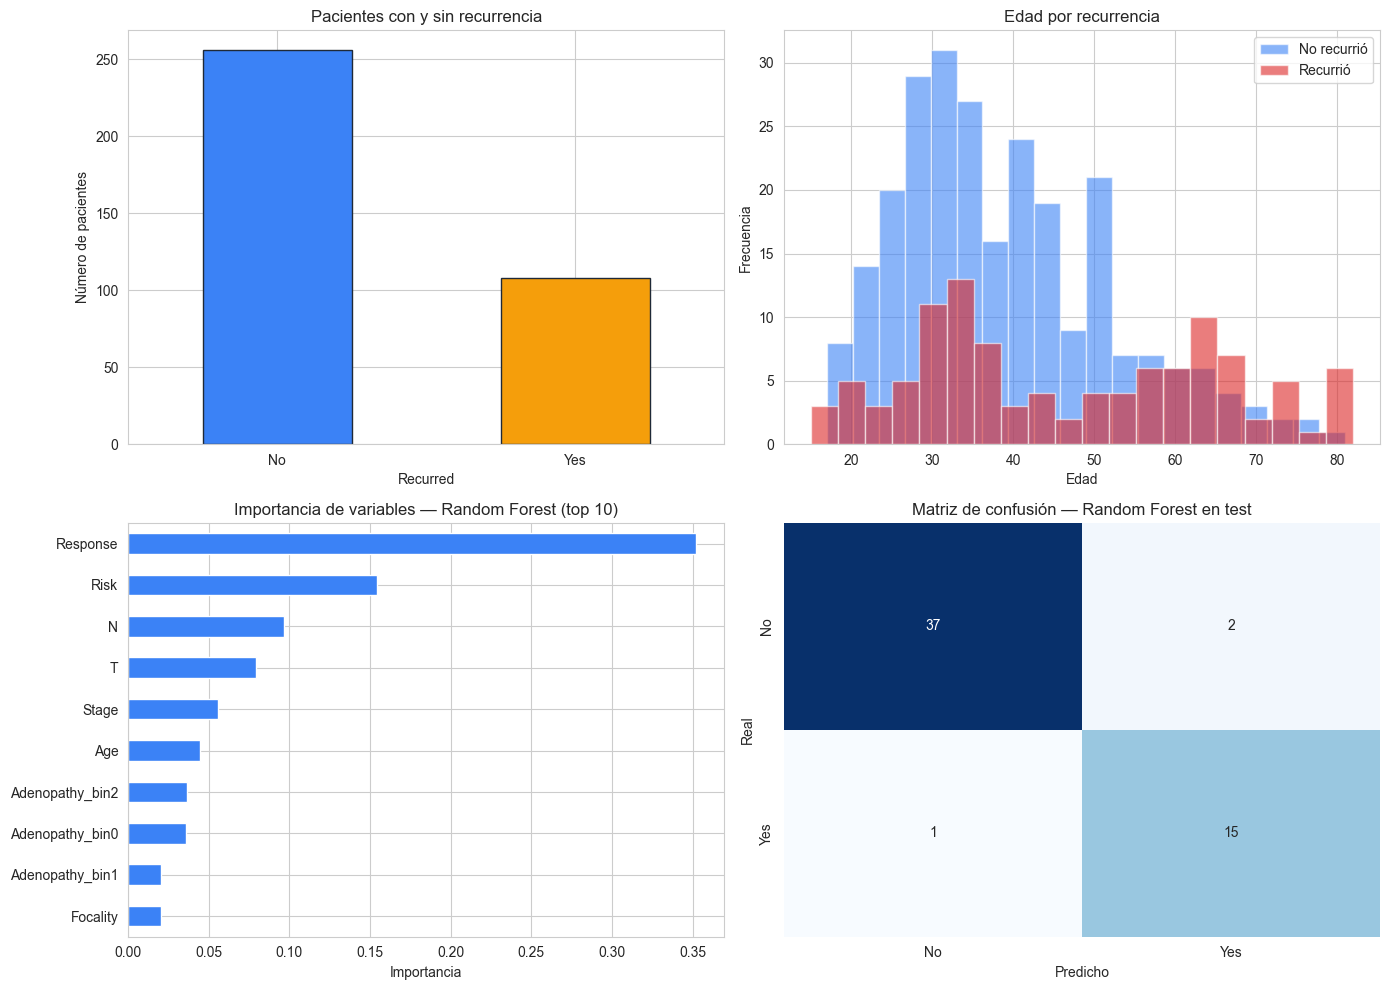

In [24]:
pred_test_final = pipeline_final_rf.predict(X_test)
matriz_final = confusion_matrix(y_test, pred_test_final)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barras: distribución del target
conteo_recurrencia.plot(kind="bar", color=["#3B82F6", "#F59E0B"], edgecolor="#1F2937", ax=axes[0, 0])
axes[0, 0].set_title("Pacientes con y sin recurrencia")
axes[0, 0].set_xlabel("Recurred")
axes[0, 0].set_ylabel("Número de pacientes")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Histograma de edad por recurrencia
axes[0, 1].hist(df.loc[df["Recurred"] == "No", "Age"], bins=20, alpha=0.6, label="No recurrió", color="#3B82F6")
axes[0, 1].hist(df.loc[df["Recurred"] == "Yes", "Age"], bins=20, alpha=0.6, label="Recurrió", color="#DC2626")
axes[0, 1].set_title("Edad por recurrencia")
axes[0, 1].set_xlabel("Edad")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].legend()

# 3. Importancia de variables (Random Forest)
top_importancias.sort_values().plot(kind="barh", color="#3B82F6", ax=axes[1, 0])
axes[1, 0].set_title("Importancia de variables — Random Forest (top 10)")
axes[1, 0].set_xlabel("Importancia")

# 4. Matriz de confusión final en test
sns.heatmap(matriz_final, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Matriz de confusión — Random Forest en test")
axes[1, 1].set_xlabel("Predicho")
axes[1, 1].set_ylabel("Real")

plt.tight_layout()
plt.show()

**¿Qué modelo funcionó mejor y por qué?** Random Forest Classifier, con el mejor F1 de validación (0,970), el Recall más alto sin señales de overfitting severo, y un desempeño en test (F1 0,938) consistente con cross validation (F1 0,929 ± 0,060). Al igual que en el problema de regresión, el ensamble por bagging generaliza mejor que un árbol individual porque reduce la varianza sin sacrificar la capacidad de capturar relaciones no lineales entre variables categóricas ordinales como `Risk`, `T`, `N`, `Stage` y `Response`.

**¿Qué le fue peor y por qué?** Gradient Boosting mostró el overfitting más marcado (Accuracy train 1,000 vs. val 0,927): con boosting, cada árbol nuevo corrige los errores del anterior de forma secuencial, lo que le da mucha capacidad de ajuste — capacidad que, con solo 254 filas de entrenamiento, termina memorizando el conjunto de entrenamiento en vez de aprender un patrón generalizable. Decision Tree tuvo el mismo problema en menor medida, por la misma razón: pocos datos, poca poda.

**¿Qué limpieza fue más determinante?** La eliminación de los 19 duplicados fue la única limpieza con impacto real (dataset ya venía sin nulos y con formato consistente). Más determinante que la limpieza fue la **codificación**: distinguir con cuidado qué variables tenían un orden clínico real (todo el sistema TNM, `Risk`, `Response`) de las que no (`Thyroid Function`, `Physical Examination`, `Pathology`, `Adenopathy`) evitó que el modelo aprendiera relaciones de orden falsas, algo que hubiera sido fácil pasar por alto con un Label Encoding automático.

**Comparación con el problema de regresión.** Los dos problemas comparten una misma conclusión metodológica: **Random Forest ganó en ambos casos**, por la misma razón de fondo (bagging reduce varianza sin perder capacidad de modelar no linealidad), y en ambos casos **KNN o los modelos con mayor capacidad de ajuste (Gradient Boosting en clasificación) mostraron las señales de overfitting o bajo desempeño más claras**. La diferencia principal entre los dos problemas fue el **tamaño del dataset**: 40.000 filas (muestreadas de 300.153) en regresión vs. apenas 364 en clasificación. Ese tamaño explica por qué en clasificación la desviación estándar del Recall en cross validation fue tan alta (0,117) comparada con la estabilidad casi perfecta del R² en regresión (0,0015): con pocos datos —y menos aún de la clase minoritaria—, cualquier modelo es más sensible a qué observaciones específicas le tocan en cada partición.

**Limitaciones y preguntas abiertas.** Con 364 pacientes y sin identificador único, no podemos descartar por completo que algunos de los "duplicados" eliminados fueran pacientes distintos con perfiles clínicos idénticos. El Recall inestable en cross validation sugiere que, antes de usar este modelo en un entorno clínico real, sería necesario validarlo con una muestra de pacientes bastante más grande. Por último, no evaluamos si el modelo es igual de bueno en el segmento de pacientes de riesgo `High` específicamente (donde más importa no fallar) — sería el siguiente paso natural antes de considerar este modelo como apoyo real a la decisión de seguimiento clínico.